# PHASE 2: HUẤN LUYỆN MÔ HÌNH MQTT
## LightGBM: CPU | XGBoost: GPU

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb
import xgboost as xgb
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

os.makedirs('Phase2_Models', exist_ok=True)
os.makedirs('Phase2_Data', exist_ok=True)

print("=" * 60)
print("PHASE 2: HUẤN LUYỆN MÔ HÌNH MQTT")
print("=" * 60)

PHASE 2: HUẤN LUYỆN MÔ HÌNH MQTT


## BƯỚC 1: LOAD DỮ LIỆU

In [2]:
print("\nBƯỚC 1: LOAD DỮ LIỆU")
print("-" * 40)

X_train = pd.read_csv('Phase1_Data/X_train_processed.csv')
X_test = pd.read_csv('Phase1_Data/X_test_processed.csv')
y_train = pd.read_csv('Phase1_Data/y_train_processed.csv').iloc[:, 0]
y_test = pd.read_csv('Phase1_Data/y_test_processed.csv').iloc[:, 0]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


BƯỚC 1: LOAD DỮ LIỆU
----------------------------------------
Train: (231646, 33), Test: (99290, 33)


## BƯỚC 2: CÂN BẰNG DỮ LIỆU

In [3]:
print("\nBƯỚC 2: CÂN BẰNG DỮ LIỆU (SMOTE + UNDERSAMPLING)")
print("-" * 40)

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

undersample = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = undersample.fit_resample(X_train_smote, y_train_smote)

print(f"Balanced: {X_train_balanced.shape}")
print(pd.Series(y_train_balanced).value_counts().sort_index())


BƯỚC 2: CÂN BẰNG DỮ LIỆU (SMOTE + UNDERSAMPLING)
----------------------------------------
Balanced: (694944, 33)
label
0    115824
1    115824
2    115824
3    115824
4    115824
5    115824
Name: count, dtype: int64


## BƯỚC 3: THIẾT LẬP MODELS

In [4]:
print("\nBƯỚC 3: THIẾT LẬP MODELS")
print("-" * 40)

models = {}

models['Decision Tree'] = DecisionTreeClassifier(
    max_depth=20, min_samples_split=10, random_state=42, class_weight='balanced'
)

models['Random Forest'] = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced'
)

models['LightGBM'] = lgb.LGBMClassifier(
    n_estimators=100, max_depth=20, learning_rate=0.1,
    num_leaves=31, random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced'
)

models['XGBoost'] = xgb.XGBClassifier(
    n_estimators=100, max_depth=20, learning_rate=0.1,
    random_state=42, tree_method='hist', device='cuda', scale_pos_weight=3.0
)

print(f"Models: {list(models.keys())}")


BƯỚC 3: THIẾT LẬP MODELS
----------------------------------------
Models: ['Decision Tree', 'Random Forest', 'LightGBM', 'XGBoost']


## BƯỚC 4: TRAINING

In [5]:
print("\nBƯỚC 4: TRAINING")
print("-" * 40)

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    start_time = time.time()
    model.fit(X_train_balanced, y_train_balanced)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {
        'model': model,
        'train_time': train_time,
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1_score': f1,
        'predictions': y_pred
    }
    
    print(f"Time: {train_time:.2f}s")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")


BƯỚC 4: TRAINING
----------------------------------------

Training Decision Tree...
Time: 1.15s
Accuracy: 0.8117
F1-Score: 0.8490

Training Random Forest...
Time: 9.39s
Accuracy: 0.8125
F1-Score: 0.8497

Training LightGBM...
Time: 6.88s
Accuracy: 0.8880
F1-Score: 0.9126

Training XGBoost...
Time: 11.62s
Accuracy: 0.8878
F1-Score: 0.9117


## BƯỚC 5: SO SÁNH MODELS

In [6]:
print("\nBƯỚC 5: SO SÁNH MODELS")
print("-" * 40)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()],
    'Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Precision': [results[m]['test_precision'] for m in results.keys()],
    'Recall': [results[m]['test_recall'] for m in results.keys()],
    'F1-Score': [results[m]['test_f1_score'] for m in results.keys()]
})

print(comparison_df.to_string(index=False))
comparison_df.to_csv('Phase2_Data/model_comparison.csv', index=False)


BƯỚC 5: SO SÁNH MODELS
----------------------------------------
        Model  Train Time (s)  Accuracy  Precision   Recall  F1-Score
Decision Tree        1.152030  0.811713   0.898048 0.811713  0.848970
Random Forest        9.390357  0.812549   0.898845 0.812549  0.849670
     LightGBM        6.879727  0.887995   0.941277 0.887995  0.912634
      XGBoost       11.618325  0.887813   0.939611 0.887813  0.911745


## BƯỚC 6: LƯU BEST MODEL

In [7]:
print("\nBƯỚC 6: LƯU BEST MODEL")
print("-" * 40)

best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']
best_metrics = results[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"F1-Score: {best_metrics['test_f1_score']:.4f}")

model_filename = 'mqtt_' + best_model_name.lower().replace(" ", "_") + '_model.pkl'
with open(f'Phase2_Models/{model_filename}', 'wb') as f:
    pickle.dump(best_model, f)

best_model_info = {
    'best_model_name': best_model_name,
    'test_accuracy': best_metrics['test_accuracy'],
    'test_precision': best_metrics['test_precision'],
    'test_recall': best_metrics['test_recall'],
    'test_f1_score': best_metrics['test_f1_score'],
    'train_time': best_metrics['train_time'],
    'model_filename': model_filename
}

with open('Phase2_Models/best_model_info.pkl', 'wb') as f:
    pickle.dump(best_model_info, f)

print("✅ Đã lưu best model")


BƯỚC 6: LƯU BEST MODEL
----------------------------------------
Best Model: LightGBM
F1-Score: 0.9126
✅ Đã lưu best model


## VISUALIZATION: MODEL COMPARISON

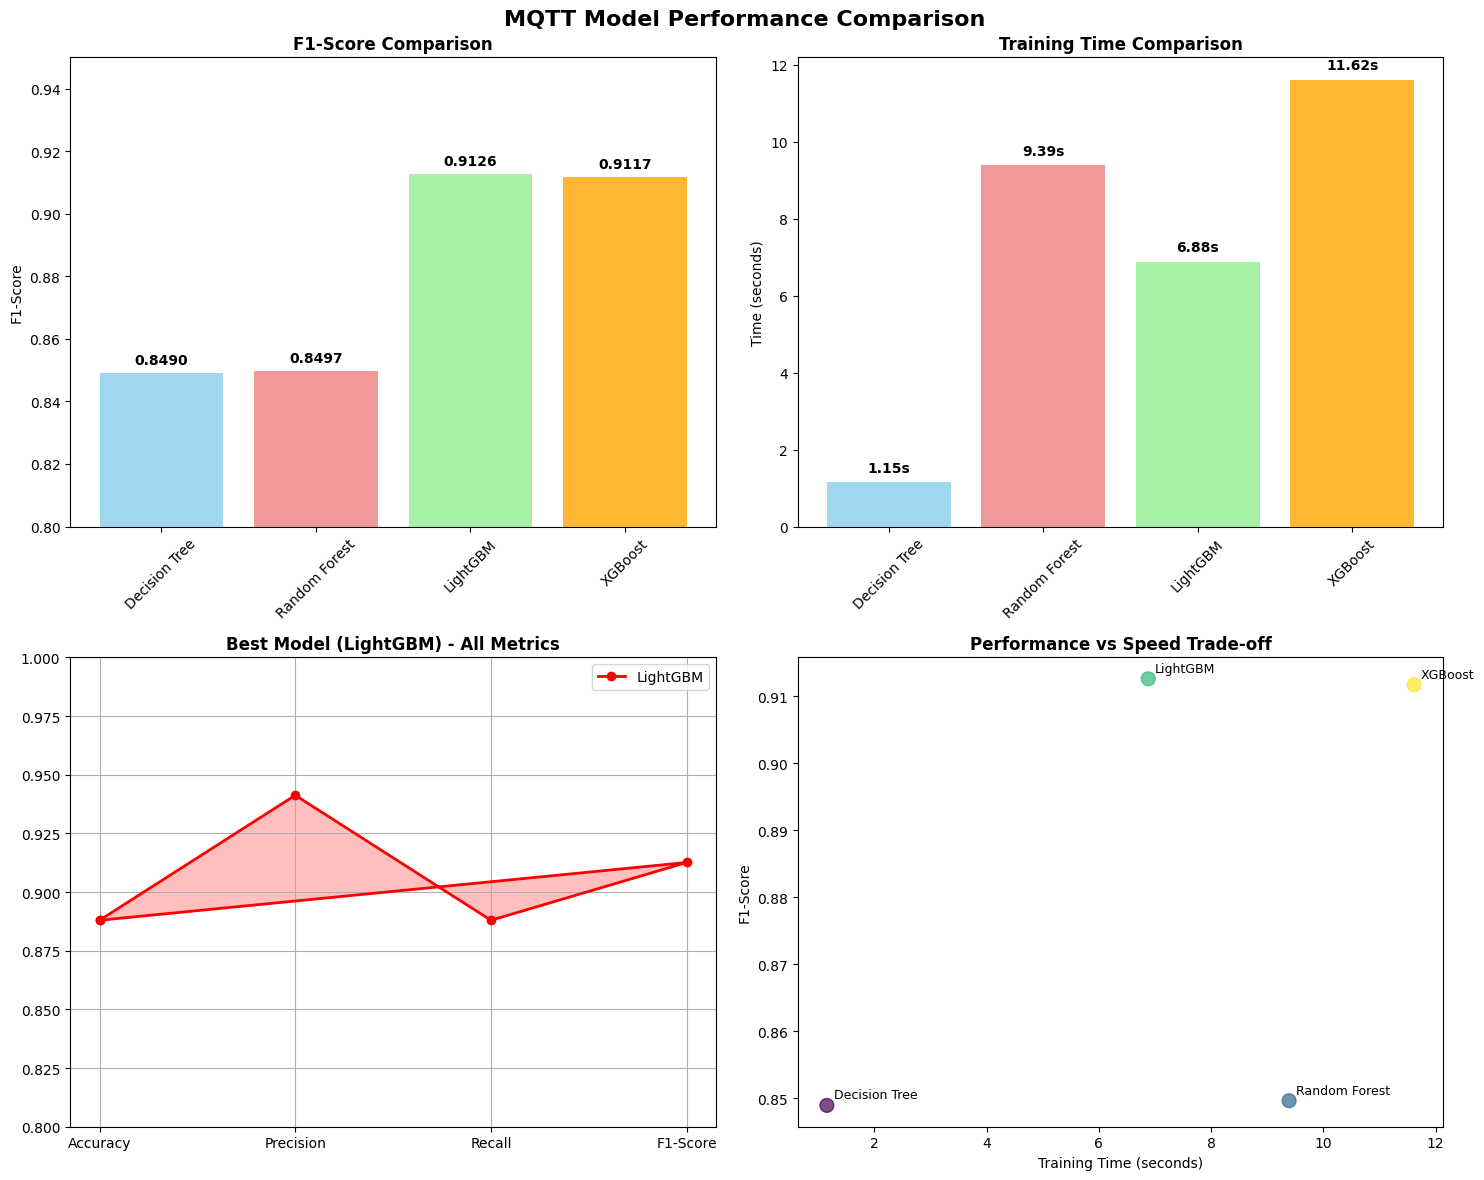


🏆 BEST MODEL SUMMARY:
Model: LightGBM
F1-Score: 0.9126
Training Time: 6.88s
Accuracy: 0.8880


In [8]:
# Model performance visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('MQTT Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. F1-Score comparison
ax1 = axes[0, 0]
models_list = list(results.keys())
f1_scores = [results[m]['test_f1_score'] for m in models_list]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']
bars = ax1.bar(models_list, f1_scores, color=colors, alpha=0.8)
ax1.set_title('F1-Score Comparison', fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0.8, 0.95)
ax1.tick_params(axis='x', rotation=45)
for bar, score in zip(bars, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Training time comparison
ax2 = axes[0, 1]
train_times = [results[m]['train_time'] for m in models_list]
bars = ax2.bar(models_list, train_times, color=colors, alpha=0.8)
ax2.set_title('Training Time Comparison', fontweight='bold')
ax2.set_ylabel('Time (seconds)')
ax2.tick_params(axis='x', rotation=45)
for bar, time_val in zip(bars, train_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')

# 3. All metrics radar chart
ax3 = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
best_model_metrics = [
    results[best_model_name]['test_accuracy'],
    results[best_model_name]['test_precision'], 
    results[best_model_name]['test_recall'],
    results[best_model_name]['test_f1_score']
]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
best_model_metrics += best_model_metrics[:1]  # Complete the circle
angles += angles[:1]

ax3.plot(angles, best_model_metrics, 'o-', linewidth=2, label=best_model_name, color='red')
ax3.fill(angles, best_model_metrics, alpha=0.25, color='red')
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(metrics)
ax3.set_ylim(0.8, 1.0)
ax3.set_title(f'Best Model ({best_model_name}) - All Metrics', fontweight='bold')
ax3.grid(True)
ax3.legend()

# 4. Performance vs Speed scatter plot
ax4 = axes[1, 1]
scatter = ax4.scatter(train_times, f1_scores, c=range(len(models_list)), 
                     s=100, alpha=0.7, cmap='viridis')
ax4.set_xlabel('Training Time (seconds)')
ax4.set_ylabel('F1-Score')
ax4.set_title('Performance vs Speed Trade-off', fontweight='bold')
for i, model in enumerate(models_list):
    ax4.annotate(model, (train_times[i], f1_scores[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig('Images/Phase2_MQTT_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print best model highlight
print(f"\n🏆 BEST MODEL SUMMARY:")
print(f"Model: {best_model_name}")
print(f"F1-Score: {best_metrics['test_f1_score']:.4f}")
print(f"Training Time: {best_metrics['train_time']:.2f}s")
print(f"Accuracy: {best_metrics['test_accuracy']:.4f}")

## VISUALIZATION: CONFUSION MATRIX & CLASSIFICATION REPORT

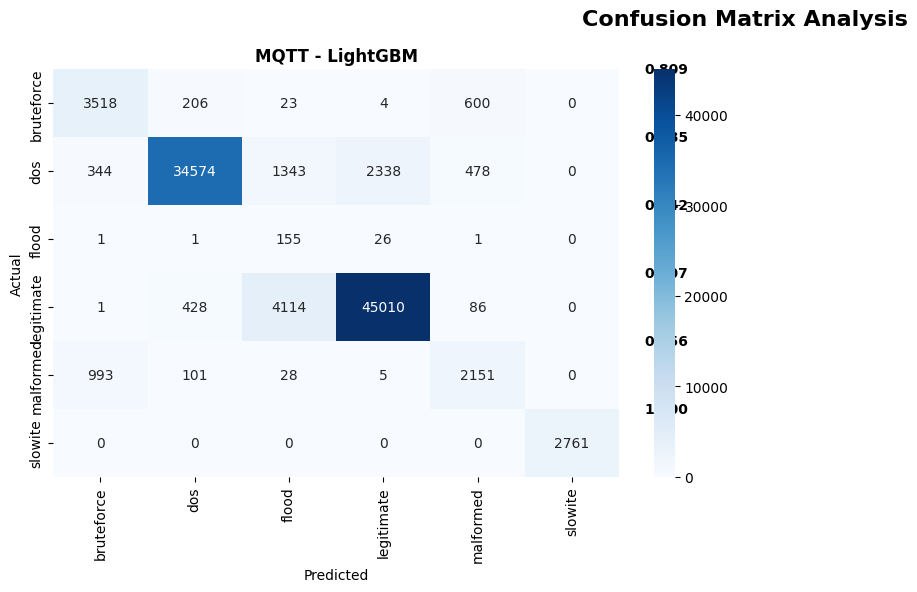

MQTT CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  bruteforce       0.72      0.81      0.76      4351
         dos       0.98      0.88      0.93     39077
       flood       0.03      0.84      0.05       184
  legitimate       0.95      0.91      0.93     49639
   malformed       0.65      0.66      0.65      3278
     slowite       1.00      1.00      1.00      2761

    accuracy                           0.89     99290
   macro avg       0.72      0.85      0.72     99290
weighted avg       0.94      0.89      0.91     99290



In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrices for best models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrix Analysis', fontsize=16, fontweight='bold')

# MQTT Confusion Matrix
ax1 = axes[0]
y_pred_mqtt = results[best_model_name]['predictions']
cm_mqtt = confusion_matrix(y_test, y_pred_mqtt)

# Load label encoder for class names
with open('Phase1_Models/mqtt_label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
class_names = label_encoder.classes_

sns.heatmap(cm_mqtt, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title(f'MQTT - {best_model_name}', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Calculate per-class accuracy
class_accuracies = cm_mqtt.diagonal() / cm_mqtt.sum(axis=1)
for i, acc in enumerate(class_accuracies):
    ax1.text(len(class_names) + 0.5, i, f'{acc:.3f}', 
             ha='center', va='center', fontweight='bold')

# Remove second subplot (not needed for MQTT)
fig.delaxes(axes[1])

plt.tight_layout()
plt.savefig('Images/Phase2_MQTT_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed classification report
print("MQTT CLASSIFICATION REPORT:")
print("=" * 50)
print(classification_report(y_test, y_pred_mqtt, target_names=class_names))

## BƯỚC 7: TEST TRÊN RAW DATASET

In [10]:
print("\nBƯỚC 7: TEST TRÊN RAW DATASET")
print("-" * 40)

# Load raw test data
test_raw = pd.read_csv('MQTT/test30_reduced.csv')
print(f"Raw test data: {test_raw.shape}")

# Load preprocessing artifacts
with open('Phase1_Models/mqtt_feature_encoders.pkl', 'rb') as f:
    feature_encoders = pickle.load(f)
with open('Phase1_Models/mqtt_label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open('Phase1_Models/mqtt_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Separate features and target
X_test_raw = test_raw.drop('target', axis=1)
y_test_raw = test_raw['target']

# Apply preprocessing
X_test_encoded = X_test_raw.copy()

# Encode categorical features
for col, encoder in feature_encoders.items():
    if col in X_test_encoded.columns:
        # Create mapping dict for speed
        mapping = {label: idx for idx, label in enumerate(encoder.classes_)}
        X_test_encoded[col] = X_test_encoded[col].map(lambda x: mapping.get(x, -1))

# Scale features
X_test_scaled = scaler.transform(X_test_encoded)

# Encode labels
y_test_encoded = label_encoder.transform(y_test_raw)

# Predict with best model
y_pred_raw = best_model.predict(X_test_scaled)

# Evaluate
accuracy_raw = accuracy_score(y_test_encoded, y_pred_raw)
precision_raw = precision_score(y_test_encoded, y_pred_raw, average='weighted', zero_division=0)
recall_raw = recall_score(y_test_encoded, y_pred_raw, average='weighted', zero_division=0)
f1_raw = f1_score(y_test_encoded, y_pred_raw, average='weighted', zero_division=0)

print(f"\nKết quả test trên RAW dataset:")
print(f"Accuracy: {accuracy_raw:.4f}")
print(f"Precision: {precision_raw:.4f}")
print(f"Recall: {recall_raw:.4f}")
print(f"F1-Score: {f1_raw:.4f}")

print(f"\nSo sánh Processed vs Raw:")
print(f"  Processed F1: {best_metrics['test_f1_score']:.4f}")
print(f"  Raw F1: {f1_raw:.4f}")
print(f"  Difference: {abs(best_metrics['test_f1_score'] - f1_raw):.4f}")


BƯỚC 7: TEST TRÊN RAW DATASET
----------------------------------------
Raw test data: (99290, 34)

Kết quả test trên RAW dataset:
Accuracy: 0.8880
Precision: 0.9413
Recall: 0.8880
F1-Score: 0.9126

So sánh Processed vs Raw:
  Processed F1: 0.9126
  Raw F1: 0.9126
  Difference: 0.0000


## VISUALIZATION: PIPELINE CONSISTENCY CHECK

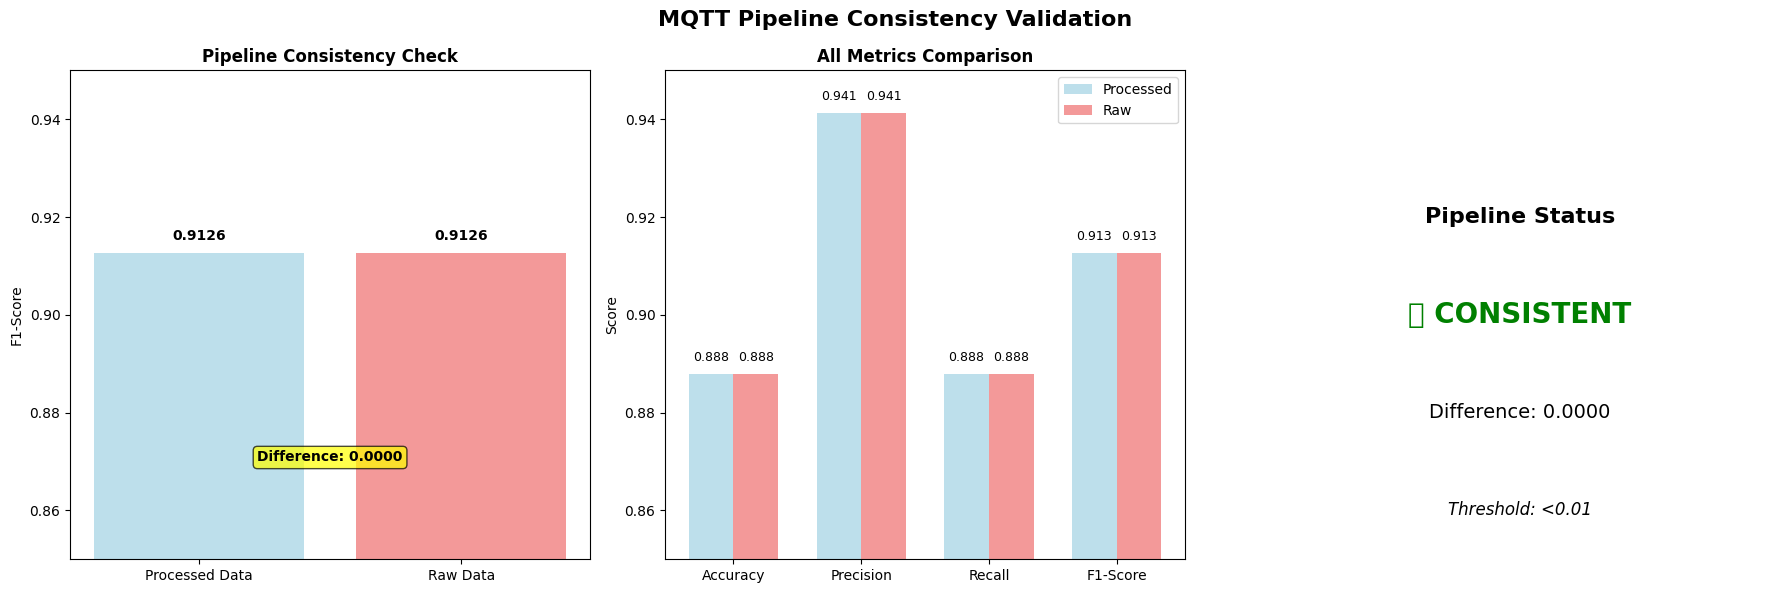

In [11]:
# Pipeline consistency visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('MQTT Pipeline Consistency Validation', fontsize=16, fontweight='bold')

# 1. Processed vs Raw F1 comparison
ax1 = axes[0]
comparison_data = ['Processed Data', 'Raw Data']
f1_comparison = [best_metrics['test_f1_score'], f1_raw]
colors = ['lightblue', 'lightcoral']
bars = ax1.bar(comparison_data, f1_comparison, color=colors, alpha=0.8)
ax1.set_title('Pipeline Consistency Check', fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0.85, 0.95)
for bar, score in zip(bars, f1_comparison):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Add difference annotation
difference = abs(best_metrics['test_f1_score'] - f1_raw)
ax1.text(0.5, 0.87, f'Difference: {difference:.4f}', ha='center', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
         fontweight='bold', transform=ax1.transData)

# 2. All metrics comparison
ax2 = axes[1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
processed_metrics = [best_metrics['test_accuracy'], best_metrics['test_precision'], 
                    best_metrics['test_recall'], best_metrics['test_f1_score']]
raw_metrics = [accuracy_raw, precision_raw, recall_raw, f1_raw]

x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax2.bar(x - width/2, processed_metrics, width, label='Processed', alpha=0.8, color='lightblue')
bars2 = ax2.bar(x + width/2, raw_metrics, width, label='Raw', alpha=0.8, color='lightcoral')

ax2.set_title('All Metrics Comparison', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.legend()
ax2.set_ylim(0.85, 0.95)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 3. Consistency status
ax3 = axes[2]
ax3.axis('off')
consistency_threshold = 0.01
is_consistent = difference < consistency_threshold

status_color = 'green' if is_consistent else 'red'
status_text = '✅ CONSISTENT' if is_consistent else '❌ INCONSISTENT'

ax3.text(0.5, 0.7, 'Pipeline Status', ha='center', va='center', fontsize=16, fontweight='bold')
ax3.text(0.5, 0.5, status_text, ha='center', va='center', fontsize=20, 
         fontweight='bold', color=status_color)
ax3.text(0.5, 0.3, f'Difference: {difference:.4f}', ha='center', va='center', fontsize=14)
ax3.text(0.5, 0.1, f'Threshold: <{consistency_threshold}', ha='center', va='center', fontsize=12, 
         style='italic')

plt.tight_layout()
plt.savefig('Images/Phase2_MQTT_pipeline_consistency.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("\n" + "=" * 60)
print("HOÀN THÀNH PHASE 2!")
print("=" * 60)
print(f"Best: {best_model_name}")
print(f"F1 (Processed): {best_metrics['test_f1_score']:.4f}")
print(f"F1 (Raw): {f1_raw:.4f}")


HOÀN THÀNH PHASE 2!
Best: LightGBM
F1 (Processed): 0.9126
F1 (Raw): 0.9126
